In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.environ['KERAS_BACKEND'] = 'jax'
import keras
import jax

import joblib

from datetime import datetime, timedelta
from model_evaluation import evaluate_model

from scipy.stats import binned_statistic_2d
import matplotlib.dates as mdates

import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FixedLocator
import calendar

import matplotlib.ticker as mticker
import datetime as dt
import matplotlib as mpl

from spacepy import pycdf

/home/gurev/Desktop/Work/Compound/.venv/lib/python3.11/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()


In [68]:
mpl.rcParams['font.size'] = 12

In [54]:
omni_clean = pd.read_hdf(f'Data/2015.03/df_with_history.h5')
best_features = np.load('Feature selection/L1 24 hours SQINV/42 features.npy', allow_pickle=True)
best_features = np.char.replace(best_features, '0.2-', '0.25-')
best_features = np.char.replace(best_features, '0.8-', '0.75-')
omni_clean = omni_clean[[col for col in best_features if ~np.isin(col, ['lg E', 'RAD', 'cosMLTcosMLAT', 'sinMLAT', 'sinMLTcosMLAT', 'PS'])]]
omni_clean = omni_clean[datetime(2015, 3, 10):datetime(2015, 3, 24)]

In [ ]:
df = pd.read_hdf('Data/PEACE_AND_RAPID/Eclipse 3D/df_march_2015.h5')
df = df.sort_values(['Time tag', 'C', 'Energy channel'])

In [56]:
start = pd.Timestamp('2015-03-10')
end = pd.Timestamp('2015-03-24')
filter_test = (df.index >= start) & (df.index < end)
df_test = df[filter_test]

In [ ]:
pos_c2 = pd.read_hdf("Data/PEACE_AND_RAPID/POS_TABLE/2015.h5")
pos_c2.index = pd.to_datetime(pos_c2.index)
filter_test = (pos_c2.index >= datetime(2015, 3, 10)) & (pos_c2.index < datetime(2015, 3, 24))
pos_c2 = pos_c2[filter_test]
pos_c2 = pos_c2[pos_c2["C"] == 2]

In [ ]:
def add_stopgrad_base(inputs):
    base, dist = inputs
    return keras.ops.stop_gradient(base) + dist

scaler = joblib.load('Models/genet-0.1.1.scaler.save')
model = keras.models.load_model('Models/genet-0.1.4_seed_4_gaussian_0.05_p50.keras', custom_objects={'loss': lambda x: None, 'pearson': lambda x: None, 'add_stopgrad_base': add_stopgrad_base})

In [59]:
x_test = df_test[scaler.feature_names_in_]
y_test = np.log10(df_test[[f'Flux {10 + i * 20}' for i in range(9)]] + 1)

In [60]:
y_base_pred, y_pred = model.predict([scaler.transform(x_test)[:, [1, 2, 3, 4, 0, 5]], scaler.transform(x_test)], batch_size=2**17)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            


In [61]:
def relu(x):
    return np.maximum(x, 0)

y_base_pred = relu(y_base_pred)
y_pred = relu(y_pred)

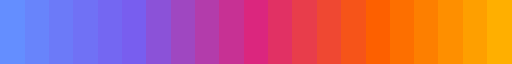

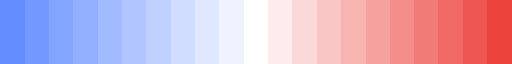

In [ ]:
ibm_cmap_full = LinearSegmentedColormap.from_list("ibm", ['#648eff', '#785eef', '#db267e', '#fd6000', '#ffaf00'], N=256)
ibm_cmap = LinearSegmentedColormap.from_list("ibm", ['#648eff', '#785eef', '#db267e', '#fd6000', '#ffaf00'], N=21)
display(ibm_cmap)

ibm_divergent = LinearSegmentedColormap.from_list("ibm", [ibm_cmap_full(0), '#ffffff', ibm_cmap_full(160)], N=21)
display(ibm_divergent)

In [65]:
def interp2d_nan(z, max_gap=None):
    """
    Fill NaNs in a 2D array by 1D linear interpolation:
      1) along time axis (axis=1)
      2) along y axis (axis=0)
    max_gap: optional, maximum consecutive-NaN run to fill (in cells). Larger gaps stay NaN.
    """
    z = np.asarray(z, dtype=float).copy()

    def interp_1d_limit(a):
        x = np.arange(a.size)
        m = np.isfinite(a)
        if m.sum() < 2:
            return a  # nothing to do
        out = a.copy()
        out[~m] = np.interp(x[~m], x[m], a[m])

        if max_gap is not None:
            nan = ~m
            if nan.any():
                # find NaN runs in original (before filling) and revert long gaps
                idx = np.flatnonzero(nan)
                # run boundaries
                splits = np.where(np.diff(idx) != 1)[0] + 1
                runs = np.split(idx, splits)
                for r in runs:
                    if len(r) > max_gap:
                        out[r] = np.nan
        return out

    # pass 1: along time (columns)
    for i in range(z.shape[0]):
        z[i, :] = interp_1d_limit(z[i, :])

    # pass 2: along y (rows)
    for j in range(z.shape[1]):
        z[:, j] = interp_1d_limit(z[:, j])

    return z


/tmp/ipykernel_2270385/817289499.py:143: RuntimeWarning: All-NaN slice encountered
  max_flux = np.nanmax(stat_i, axis=0)
/tmp/ipykernel_2270385/817289499.py:145: RuntimeWarning: invalid value encountered in divide
  stat_i /= 10**max_flux-1
/tmp/ipykernel_2270385/817289499.py:154: RuntimeWarning: All-NaN slice encountered
  max_flux = np.nanmax(stat_i, axis=0)


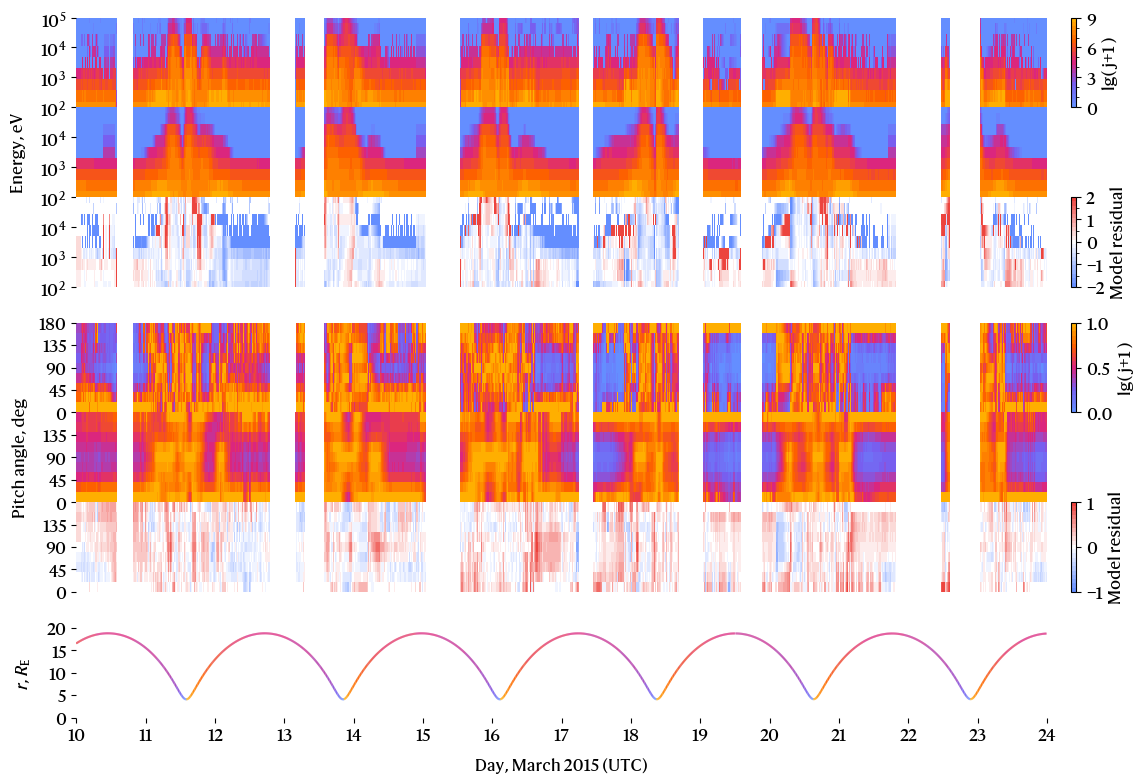

In [72]:
fig = plt.figure(figsize=(10, 7))

# 2 columns: main plots + colorbars
gs = fig.add_gridspec(
    nrows=9, ncols=2,
    width_ratios=[1.0, 0.005],                 # <- fixed colorbar column
    height_ratios=[1, 1, 1, 0.4, 1, 1, 1, 0.4, 1],
    wspace=0.05, hspace=0.0
)

# main axes (col 0)
ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[2, 0]),
    fig.add_subplot(gs[4, 0]),
    fig.add_subplot(gs[5, 0]),
    fig.add_subplot(gs[6, 0]),
    fig.add_subplot(gs[8, 0]),
]

# colorbar axes (col 1) for the rows that need them
cax = {
    0: fig.add_subplot(gs[0, 1]),
    1: fig.add_subplot(gs[1, 1]),
    2: fig.add_subplot(gs[2, 1]),
    3: fig.add_subplot(gs[4, 1]),
    4: fig.add_subplot(gs[5, 1]),
    5: fig.add_subplot(gs[6, 1]),
    6: fig.add_subplot(gs[8, 1]),  # <- reserve width for the last line plot
}

n_t_bins = 14 * 24 * 60 // 20
# n_t_bins = 14 * 24 * 60
max_gap = 3 * 60 // (14 * 24 * 60 // n_t_bins)

filter_c = df_test['C'] == 2

time_sec = df_test[filter_c].index.astype('int64') / 1e9
energy = df_test[filter_c]['lg E']
flux = np.log10(df_test[filter_c]['Flux 90'] + 1)
pred_flux = y_pred[filter_c][:, 4]

# Bins
centers = np.linspace(2, 5, 9)
mid = (centers[1:] + centers[:-1]) * 0.5
first_edge = centers[0] - (mid[0] - centers[0])
last_edge  = centers[-1] + (centers[-1] - mid[-1])
e_bins = np.concatenate(([first_edge], mid, [last_edge]))
t_bins = np.linspace(time_sec.min(), time_sec.max(), n_t_bins)

def binned_stat(x, y, z, bins, extra_mask=None):
    # mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    mask = np.isfinite(z)
    if extra_mask is not None:
        mask = mask & extra_mask
    # mask = np.ones_like(x).astype(bool)
    stat, _, _, _ = binned_statistic_2d(
        x[mask], y[mask], z[mask],
        # statistic=lambda v: np.nanmean(v) if len(v) else np.nan,
        statistic=lambda v: np.nanmedian(v) if len(v) else np.nan,
        bins=bins
    )
    return stat

# panel-2 availability mask -> reuse in panel 1 so gaps match
shared_mask = np.isfinite(pred_flux)

stat = binned_stat(energy.values, time_sec.values, flux.values, bins=[e_bins, t_bins], extra_mask=shared_mask)
stat_i = interp2d_nan(stat, max_gap=max_gap)
stat_i_1 = stat_i.copy()
pcm = ax[0].pcolormesh(t_bins, 10**e_bins, stat_i, shading='auto', cmap=ibm_cmap, vmin=0, vmax=9)
ax[0].set_yscale('log')
cbar = fig.colorbar(pcm, cax=cax[0], label='lg( j+1 )')
cbar.ax.set_yticks(np.arange(0, 9.1, 3), minor=False)
cbar.ax.set_yticks(np.arange(0, 9.1, 1), minor=True)

stat = binned_stat(energy.values, time_sec.values, pred_flux, bins=[e_bins, t_bins])
stat_i = interp2d_nan(stat, max_gap=max_gap)
stat_i_2 = stat_i.copy()
pcm = ax[1].pcolormesh(t_bins, 10**e_bins, stat_i, shading='auto', cmap=ibm_cmap, vmin=0, vmax=9)
ax[1].set_yscale('log')
# fig.colorbar(pcm, cax=cax[1], label='Flux')
cax[1].axis('off')

# stat = binned_stat(energy.values, time_sec.values, (pred_flux - flux.values), bins=[e_bins, t_bins])
# stat_i = interp2d_nan(stat, max_gap=max_gap)
pcm = ax[2].pcolormesh(t_bins, 10**e_bins, stat_i_2 - stat_i_1, shading='auto', cmap=ibm_divergent, vmin=-2, vmax=2)
ax[2].set_yscale('log')
cbar = fig.colorbar(pcm, cax=cax[2], label='Model residual')
cbar.ax.set_yticks(np.arange(-2, 2.1, 1), minor=False)
cbar.ax.set_yticks(np.arange(-2, 2.1, 0.5), minor=True)

##


# ax[6].step(omni_clean.index[::30].astype('int64') / 1e9, omni_clean['Hp30'][::30], where='post', c='#58595b')

# r = pos_c2['RAD'] / 6378
# time = pos_c2.index.astype('int64') / 1e9
# ax[6].plot(time, r, c='#58595b')
# ax[6].plot(time, pos_c2['MLAT'], c='#58595b')

pos_c2_5min = pos_c2.resample("10min").median()
x = pos_c2_5min.index.astype("int64") / 1e9
y = pos_c2_5min["RAD"] / 6378
seg = np.stack([np.c_[x[:-1], y[:-1]], np.c_[x[1:], y[1:]]], axis=1)

from matplotlib.collections import LineCollection
lc = LineCollection(seg, cmap=ibm_cmap)
lc.set_array(pos_c2_5min["MLT"].to_numpy()[:-1])
lc.set_clim(0, 24)
ax[6].add_collection(lc)
ax[6].autoscale()

cax[6].axis('off')

##

df_test_pa = pd.concat([df_test.drop(columns=[f'Flux {10 + 20 * i}' for i in range(9) if i != j]).rename(columns={f'Flux {10 + 20 * j}': 'Flux'}) for j in range(9)])
df_test_pa['Pitch angle'] = np.repeat(np.arange(10, 180, 20), len(df_test))
df_test_pa = df_test_pa.sort_values(['Time tag', 'C', 'Energy channel', 'Pitch angle'])

filter_c = df_test_pa['C'] == 2
filter_e = df_test_pa['Energy channel'] == 1
filter = filter_c & filter_e

time_sec = df_test_pa[filter].index.astype('int64') / 1e9
pitch_angle = df_test_pa[filter]['Pitch angle']
flux = np.log10(1 + df_test_pa[filter]['Flux'])
pred_flux = np.concatenate(y_pred)[filter]
# pred_flux = np.concatenate(base_pred)[filter]

# Bins
a_bins = np.arange(0, 181, 20)
t_bins = np.linspace(time_sec.min(), time_sec.max(), n_t_bins)

shared_mask = np.isfinite(pred_flux)
stat = binned_stat(pitch_angle.values, time_sec.values, flux.values, bins=[a_bins, t_bins], extra_mask=shared_mask)
stat_i = interp2d_nan(stat, max_gap=max_gap)
# omnidir_flux = np.sum([(10**stat_i[j, ...]-1) * np.sin(np.deg2rad(10+20*j)) for j in range(9)], axis=0) / np.sum(np.sin(np.deg2rad(np.linspace(10, 180, 20))))
# stat_i /= np.log10(omnidir_flux + 1)
max_flux = np.nanmax(stat_i, axis=0)
stat_i = 10**stat_i-1
stat_i /= 10**max_flux-1
stat_i_1 = stat_i.copy()
pcm = ax[3].pcolormesh(t_bins, a_bins, stat_i, shading='auto', cmap=ibm_cmap, vmin=0, vmax=1)
cbar = fig.colorbar(pcm, cax=cax[3], label='lg( j+1 )')
# cbar.ax.set_yticks(np.arange(7, 9.1, 1), minor=False)
# cbar.ax.set_yticks(np.arange(7, 9.1, 0.5), minor=True)

stat = binned_stat(pitch_angle.values, time_sec.values, pred_flux, bins=[a_bins, t_bins])
stat_i = interp2d_nan(stat, max_gap=max_gap)
max_flux = np.nanmax(stat_i, axis=0)
stat_i = 10**stat_i-1
stat_i /= 10**max_flux-1
stat_i_2 = stat_i.copy()
pcm = ax[4].pcolormesh(t_bins, a_bins, stat_i, shading='auto', cmap=ibm_cmap, vmin=0, vmax=1)
# fig.colorbar(pcm, cax=cax[4], label='Flux')
cax[4].axis('off')

# stat = binned_stat(pitch_angle.values, time_sec.values, (pred_flux - flux.values), bins=[a_bins, t_bins])
# stat = binned_stat(pitch_angle.values, time_sec.values, (pred_flux - flux.values), bins=[a_bins, t_bins])
# stat_i = interp2d_nan(stat, max_gap=max_gap)
pcm = ax[5].pcolormesh(t_bins, a_bins, stat_i_2 - stat_i_1, shading='auto', cmap=ibm_divergent, vmin=-1, vmax=1)
cbar = fig.colorbar(pcm, cax=cax[5], label='Model residual')
# cbar.ax.set_yticks(np.arange(-2, 2.1, 1), minor=False)
# cbar.ax.set_yticks(np.arange(-2, 2.1, 0.5), minor=True)

for axis in ax:
    start = calendar.timegm(dt.datetime(2015, 3, 10).timetuple())
    end = calendar.timegm(dt.datetime(2015, 3, 24).timetuple())
    axis.set_xlim(start, end)
    
    # One tick per day
    axis.xaxis.set_major_locator(mticker.MultipleLocator(86400))
    axis.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: dt.datetime.utcfromtimestamp(x).strftime('%d')))

    for spine in axis.spines.values():
        spine.set_visible(False)

ax[1].set_ylabel('Energy, eV', labelpad=10)
# ax[4].set_ylabel('$\\mathbf{Pitch angle, deg}$', math_fontfamily='custom')
ax[4].set_ylabel('Pitch angle, deg', labelpad=10)
ax[6].set_ylabel('$r$, $R_\mathrm{E}$', labelpad=10, math_fontfamily='custom')

for i in range(6):
    ax[i].set_xticks([])

ax[6].set_xlabel('Day, March 2015 (UTC)', labelpad=10)

# for i in range(14):
#     ax[6].axvline(calendar.timegm(dt.datetime(2015, 3, 10+i).timetuple()), linewidth=0.5, c='#a6a8ab')

for i in range(3):
    ax[i].set_ylim([1e2, 1e5])
    ax[i].set_yticks([1e2, 1e3, 1e4])
ax[0].set_yticks([1e2, 1e3, 1e4, 1e5])

for i in range(3, 6):
    ax[i].set_ylim([0, 180])
    ax[i].set_yticks(np.arange(0, 180, 45))
ax[3].set_yticks(np.arange(0, 181, 45))

# ax[6].set_ylim([0, 9])
# ax[6].set_yticks(np.arange(0, 10, 3))
ax[6].set_ylim([0, 20])
ax[6].set_yticks(np.arange(0, 21, 5))

fig.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=0)

# for i in range(6):
#     ax[i].cla()
fig.savefig('Plots/spectrograms.pdf', bbox_inches='tight')

# fig.savefig('Plots/spectrograms.png', dpi=600, bbox_inches='tight')

plt.show()

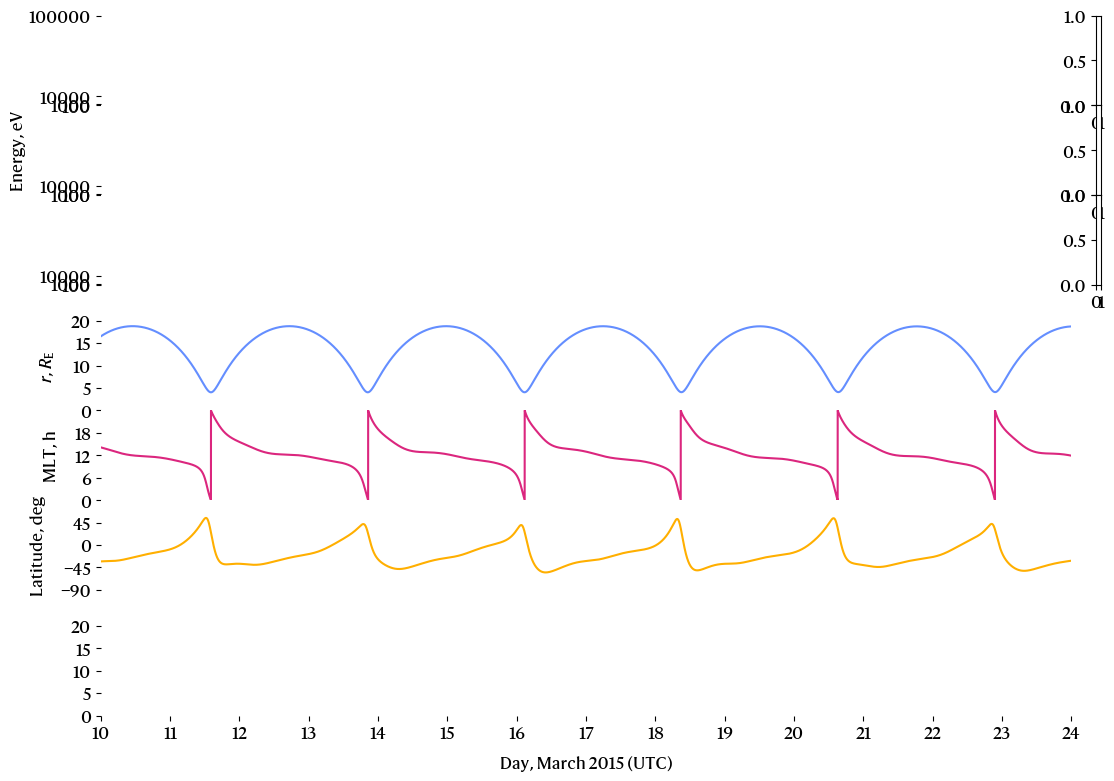

In [102]:
fig = plt.figure(figsize=(10, 7))

# 2 columns: main plots + colorbars
gs = fig.add_gridspec(
    nrows=9, ncols=2,
    width_ratios=[1.0, 0.005],                 # <- fixed colorbar column
    height_ratios=[1, 1, 1, 0.4, 1, 1, 1, 0.4, 1],
    wspace=0.05, hspace=0.0
)

# main axes (col 0)
ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[2, 0]),
    fig.add_subplot(gs[4, 0]),
    fig.add_subplot(gs[5, 0]),
    fig.add_subplot(gs[6, 0]),
    fig.add_subplot(gs[8, 0]),
]

# colorbar axes (col 1) for the rows that need them
cax = {
    0: fig.add_subplot(gs[0, 1]),
    1: fig.add_subplot(gs[1, 1]),
    2: fig.add_subplot(gs[2, 1]),
    3: fig.add_subplot(gs[4, 1]),
    # 4: fig.add_subplot(gs[5, 1]),
    # 5: fig.add_subplot(gs[6, 1]),
    # 6: fig.add_subplot(gs[8, 1]),  # <- reserve width for the last line plot
}

n_t_bins = 14 * 24 * 60 // 20
# n_t_bins = 14 * 24 * 60
max_gap = 3 * 60 // (14 * 24 * 60 // n_t_bins)

filter_c = df_test['C'] == 2

time_sec = df_test[filter_c].index.astype('int64') / 1e9
energy = df_test[filter_c]['lg E']
flux = np.log10(df_test[filter_c]['Flux 90'] + 1)
pred_flux = y_pred[filter_c][:, 4]

# Bins
centers = np.linspace(2, 5, 9)
mid = (centers[1:] + centers[:-1]) * 0.5
first_edge = centers[0] - (mid[0] - centers[0])
last_edge  = centers[-1] + (centers[-1] - mid[-1])
e_bins = np.concatenate(([first_edge], mid, [last_edge]))
t_bins = np.linspace(time_sec.min(), time_sec.max(), n_t_bins)

def binned_stat(x, y, z, bins, extra_mask=None):
    # mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    mask = np.isfinite(z)
    if extra_mask is not None:
        mask = mask & extra_mask
    # mask = np.ones_like(x).astype(bool)
    stat, _, _, _ = binned_statistic_2d(
        x[mask], y[mask], z[mask],
        # statistic=lambda v: np.nanmean(v) if len(v) else np.nan,
        statistic=lambda v: np.nanmedian(v) if len(v) else np.nan,
        bins=bins
    )
    return stat

# # panel-2 availability mask -> reuse in panel 1 so gaps match
# shared_mask = np.isfinite(pred_flux)

# stat = binned_stat(energy.values, time_sec.values, flux.values, bins=[e_bins, t_bins], extra_mask=shared_mask)
# stat_i = interp2d_nan(stat, max_gap=max_gap)
# stat_i_1 = stat_i.copy()
# pcm = ax[0].pcolormesh(t_bins, 10**e_bins, stat_i, shading='auto', cmap=ibm_cmap, vmin=0, vmax=9)
# ax[0].set_yscale('log')
# cbar = fig.colorbar(pcm, cax=cax[0], label='lg( j+1 )')
# cbar.ax.set_yticks(np.arange(0, 9.1, 3), minor=False)
# cbar.ax.set_yticks(np.arange(0, 9.1, 1), minor=True)

# stat = binned_stat(energy.values, time_sec.values, pred_flux, bins=[e_bins, t_bins])
# stat_i = interp2d_nan(stat, max_gap=max_gap)
# stat_i_2 = stat_i.copy()
# pcm = ax[1].pcolormesh(t_bins, 10**e_bins, stat_i, shading='auto', cmap=ibm_cmap, vmin=0, vmax=9)
# ax[1].set_yscale('log')
# # fig.colorbar(pcm, cax=cax[1], label='Flux')
# cax[1].axis('off')

# # stat = binned_stat(energy.values, time_sec.values, (pred_flux - flux.values), bins=[e_bins, t_bins])
# # stat_i = interp2d_nan(stat, max_gap=max_gap)
# pcm = ax[2].pcolormesh(t_bins, 10**e_bins, stat_i_2 - stat_i_1, shading='auto', cmap=ibm_divergent, vmin=-2, vmax=2)
# ax[2].set_yscale('log')
# cbar = fig.colorbar(pcm, cax=cax[2], label='Model residual')
# cbar.ax.set_yticks(np.arange(-2, 2.1, 1), minor=False)
# cbar.ax.set_yticks(np.arange(-2, 2.1, 0.5), minor=True)

##


# ax[6].step(omni_clean.index[::30].astype('int64') / 1e9, omni_clean['Hp30'][::30], where='post', c='#58595b')

# r = pos_c2['RAD'] / 6378
# time = pos_c2.index.astype('int64') / 1e9
# ax[6].plot(time, r, c='#58595b')
# ax[6].plot(time, pos_c2['MLAT'], c='#58595b')

# pos_c2_5min = pos_c2.resample("5min").median()
# x = pos_c2_5min.index.astype("int64") / 1e9
# y = pos_c2_5min["RAD"] / 6378
# seg = np.stack([np.c_[x[:-1], y[:-1]], np.c_[x[1:], y[1:]]], axis=1)

# from matplotlib.collections import LineCollection
# lc = LineCollection(seg, cmap=ibm_cmap)
# lc.set_array(pos_c2_5min["MLT"].to_numpy()[:-1])
# lc.set_clim(0, 24)
# ax[6].add_collection(lc)
# ax[6].autoscale()

time = pos_c2.index.astype('int64') / 1e9
r = pos_c2['RAD'] / 6378
lat = pos_c2['MLAT']
mlt = pos_c2['MLT']
ax[3].plot(time, r, c=ibm_cmap(0))
ax[4].plot(time, mlt, c=ibm_cmap(10))
ax[5].plot(time, lat, c=ibm_cmap(21))

cax[3].axis('off')

##

for axis in ax:
    start = calendar.timegm(dt.datetime(2015, 3, 10).timetuple())
    end = calendar.timegm(dt.datetime(2015, 3, 24).timetuple())
    axis.set_xlim(start, end)
    
    # One tick per day
    axis.xaxis.set_major_locator(mticker.MultipleLocator(86400))
    axis.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: dt.datetime.utcfromtimestamp(x).strftime('%d')))

    for spine in axis.spines.values():
        spine.set_visible(False)

ax[1].set_ylabel('Energy, eV', labelpad=10)
# ax[4].set_ylabel('$\\mathbf{Pitch angle, deg}$', math_fontfamily='custom')
ax[3].set_ylabel('$r$, $R_\mathrm{E}$', labelpad=10, math_fontfamily='custom')
ax[4].set_ylabel('MLT, h', labelpad=10, math_fontfamily='custom')
ax[5].set_ylabel('Latitude, deg', labelpad=10, math_fontfamily='custom')

for i in range(6):
    ax[i].set_xticks([])

ax[6].set_xlabel('Day, March 2015 (UTC)', labelpad=10)

# for i in range(14):
#     ax[6].axvline(calendar.timegm(dt.datetime(2015, 3, 10+i).timetuple()), linewidth=0.5, c='#a6a8ab')

for i in range(3):
    ax[i].set_ylim([1e2, 1e5])
    ax[i].set_yticks([1e2, 1e3, 1e4])
ax[0].set_yticks([1e2, 1e3, 1e4, 1e5])

ax[3].set_ylim([0, 20])
ax[3].set_yticks(np.arange(0, 21, 5))

ax[4].set_ylim([0, 24])
ax[4].set_yticks(np.arange(0, 24, 6))

ax[5].set_ylim([-90, 90])
ax[5].set_yticks(np.arange(-90, 90, 45))

# ax[6].set_ylim([0, 9])
# ax[6].set_yticks(np.arange(0, 10, 3))
ax[6].set_ylim([0, 20])
ax[6].set_yticks(np.arange(0, 21, 5))

fig.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=0)

# for i in range(6):
#     ax[i].cla()
fig.savefig('Plots/spectrograms_position.pdf', bbox_inches='tight')

# fig.savefig('Plots/spectrograms.png', dpi=600, bbox_inches='tight')

plt.show()